In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("Pharma_Industry.csv")
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [5]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [6]:
df.isnull().sum()

,0
Drug Dosage (mg),0
Systolic Blood Pressure (mmHg),0
Heart Rate (BPM),0
Liver Toxicity Index (U/L),0
Blood Glucose Level (mg/dL),0
Drug Response,0


In [7]:
df.dtypes

,0
Drug Dosage (mg),float64
Systolic Blood Pressure (mmHg),float64
Heart Rate (BPM),float64
Liver Toxicity Index (U/L),float64
Blood Glucose Level (mg/dL),float64
Drug Response,int64


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Drug Response'] = le.fit_transform(df['Drug Response'])

df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [9]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [10]:
X = df.drop('Drug Response', axis=1)
y = df['Drug Response']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [12]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [13]:
y_pred = svm_model.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.78


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100



In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[36  8]
 [14 42]]


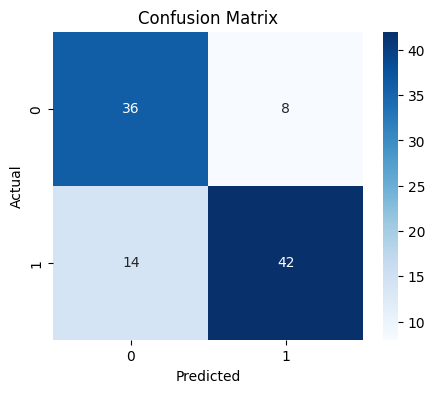

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [18]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

kernels = ['linear', 'rbf', 'poly']

for k in kernels:
    model = SVC(kernel=k, random_state=42)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    print("Kernel:", k)
    print("Accuracy:", accuracy_score(y_test, pred))
    print("----------------------------")

Kernel: linear
Accuracy: 0.78
----------------------------
Kernel: rbf
Accuracy: 0.82
----------------------------
Kernel: poly
Accuracy: 0.69
----------------------------


Linear Kernel:
Suitable for linearly separable data. Fast and easy to interpret.

RBF Kernel:
Handles complex non-linear relationships and often gives better accuracy.

Polynomial Kernel:
Captures polynomial relationships but may take more computation time.

Strengths of SVM

• Works well on small and medium-sized datasets.
• Effective in high-dimensional data.
• Provides good classification accuracy.

Weaknesses of SVM

• Training can be slow for very large datasets.
• Choosing the correct kernel is important.
• Less interpretable than simple models like Logistic Regression.

Real-world Applications

• Disease diagnosis
• Drug response prediction
• Face recognition
• Fraud detection
• Spam email classification

Conclusion: Among the three kernels tested, the RBF kernel achieved the highest accuracy (82%). Therefore, it is the most suitable kernel for this drug response classification dataset because it captures non-linear relationships better than the Linear and Polynomial kernels.

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf', 'poly']
}

grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.74


In [20]:
best_svm = SVC(
    C=grid_search.best_params_['C'],
    gamma=grid_search.best_params_['gamma'],
    kernel=grid_search.best_params_['kernel'],
    random_state=42
)

best_svm.fit(X_train, y_train)

SVC(C=1, gamma='auto', random_state=42)

In [24]:
y_pred_best = best_svm.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score

tuned_accuracy = accuracy_score(y_test, y_pred_best)

print("Tuned SVM Test Accuracy:", tuned_accuracy)

Tuned SVM Test Accuracy: 0.83


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.79      0.84      0.81        44
           1       0.87      0.82      0.84        56

    accuracy                           0.83       100
   macro avg       0.83      0.83      0.83       100
weighted avg       0.83      0.83      0.83       100



In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_best)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[37  7]
 [10 46]]


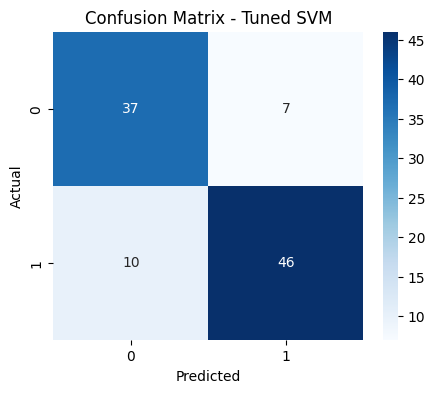

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned SVM")

plt.show()

### Hyperparameter Tuning Conclusion

Hyperparameter tuning was performed using GridSearchCV to identify the best parameters for the SVM model. The best parameters obtained were C = 1, gamma = 'auto', and kernel = 'rbf'. The tuned SVM achieved a test accuracy of 83%, which improved from the initial SVM accuracy of 78%. Therefore, hyperparameter tuning improved the model's performance, and the RBF kernel with the selected parameters is the best configuration for this dataset.